# **Machine Learning for Sentiment Clasification with the CREMA-D dataset**

### **1. Load and understanding the dataset (Exploration and features)**

*Based on the official documentation (kaggle and GitHub), about the dataset. We can retrieve the following information.*

#### **1.1 Description of the dataset**

CREMA-D is a data set of **7,442** original clips from **91 actors**. These clips were from *48 male and 43 female* actors between the ages of *20 and 74* coming from a variety of races and ethnicities **(African America, Asian, Caucasian, Hispanic, and Unspecified).**

Actors spoke from a selection of **12 sentences**. The sentences were presented using one of six different emotions **(Anger, Disgust, Fear, Happy, Neutral and Sad)** and *four* different emotion levels **(Low, Medium, High and Unspecified).**

Participants rated the emotion and emotion levels based on the combined audiovisual presentation, the video alone, and the audio alone. Due to the large number of ratings needed, this effort was crowd-sourced and a total of 2443 participants each rated 90 unique clips, 30 audio, 30 visual, and 30 audio-visual. 95% of the clips have more than 7 ratings.


---

#### **1.2 Filename labeling conventions**

The Actor id is a 4 digit number at the start of the file. Each subsequent identifier is separated by an underscore (_).

Actors spoke from a selection of 12 sentences (in parentheses is the three letter acronym used in the second part of the filename):

- *It's eleven o'clock (IEO).*
- *That is exactly what happened (TIE).*
- *I'm on my way to the meeting (IOM).*
- *I wonder what this is about (IWW).*
- *The airplane is almost full (TAI).*
- *Maybe tomorrow it will be cold (MTI).*
- *I would like a new alarm clock (IWL).*
- *I think I have a doctor's appointment (ITH).*
- *Don't forget a jacket (DFA).*
- *I think I've seen this before (ITS).*
- *The surface is slick (TSI).*
- *We'll stop in a couple of minutes (WSI).*

The sentences were presented using different emotion (in parentheses is the three letter code used in the third part of the filename):

- *Anger (ANG)*
- *Disgust (DIS)*
- *Fear (FEA)*
- *Happy/Joy (HAP)*
- *Neutral (NEU)*
- *Sad (SAD)*

and emotion level (in parentheses is the two letter code used in the fourth part of the filename):

- *Low (LO)*
- *Medium (MD)*
- *High (HI)*
- *Unspecified (XX)*

The suffix of the filename is based on the type of file, flv for flash video used for presentation of both the video only, and the audio-visual clips. mp3 is used for the audio files used for the audio-only presentation of the clips. wav is used for files used for computational audio processing.

---

Let's see the first five files of the dataset to have a better view about the different prefixes used for each characteristic of the audio.

In [1]:
DATASET_ROOT = 'data/AudioWAV'

In [2]:
import os
import  IPython.display as ipd

files = os.listdir(DATASET_ROOT)
print(f"First five files: {files[:5]}")

# Playing the audios on interactive form 
for file_name in files[:5]:
    path_file = os.path.join(DATASET_ROOT, file_name)

    print(f"Play audio {file_name}")
    ipd.display(ipd.Audio(path_file))

First five files: ['1001_DFA_ANG_XX.wav', '1001_DFA_DIS_XX.wav', '1001_DFA_FEA_XX.wav', '1001_DFA_HAP_XX.wav', '1001_DFA_NEU_XX.wav']
Play audio 1001_DFA_ANG_XX.wav


Play audio 1001_DFA_DIS_XX.wav


Play audio 1001_DFA_FEA_XX.wav


Play audio 1001_DFA_HAP_XX.wav


Play audio 1001_DFA_NEU_XX.wav


In [3]:
print(f"Number of the audios on the dataset: {len(files)}")

Number of the audios on the dataset: 7442


### **Analyze the class distribution**

Let's analyze the class distribution per emotions classes, and the level of emotions using a bar and stacked bar plot for having a more visual understanding about our data.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

EMOTION_MAP = {
    'ANG': 'Anger',
    'DIS': 'Disgust',
    'FEA': 'Fear',
    'HAP': 'Happy/Joy',
    'NEU': 'Neutral',
    'SAD': 'Sad'
}

def extract_emotions(dataset_path):
    """
    Parses audio filenames from the CREMA-D dataset directory,
    extracts the emotion code (3rd part: index 2), and returns a DataFrame.
    """
    data = []
    
    for file_name in os.listdir(dataset_path):
        if file_name.endswith('.wav'):
            parts = file_name.split('_')
            
            # The emotion code is the third part (index 2)
            if len(parts) >= 3:
                emotion_code = parts[2]
                if emotion_code in EMOTION_MAP:
                    data.append({
                        'filename': file_name,
                        'emotion_code': emotion_code,
                        'emotion': EMOTION_MAP[emotion_code]
                    })
                    
    return pd.DataFrame(data)

In [5]:
df_emotions = extract_emotions(DATASET_ROOT)

df_emotions.sample(5)

,filename,emotion_code,emotion
1852,1023_TIE_HAP_XX.wav,HAP,Happy/Joy
2265,1028_TSI_ANG_XX.wav,ANG,Anger
5035,1062_MTI_ANG_XX.wav,ANG,Anger
1284,1016_TIE_HAP_XX.wav,HAP,Happy/Joy
3791,1047_ITS_NEU_XX.wav,NEU,Neutral


In [6]:
emotion_counts = df_emotions['emotion'].value_counts()
print("Class Distribution:\n", emotion_counts)

Class Distribution:
 emotion
Anger        1271
Disgust      1271
Fear         1271
Happy/Joy    1271
Sad          1271
Neutral      1087
Name: count, dtype: int64


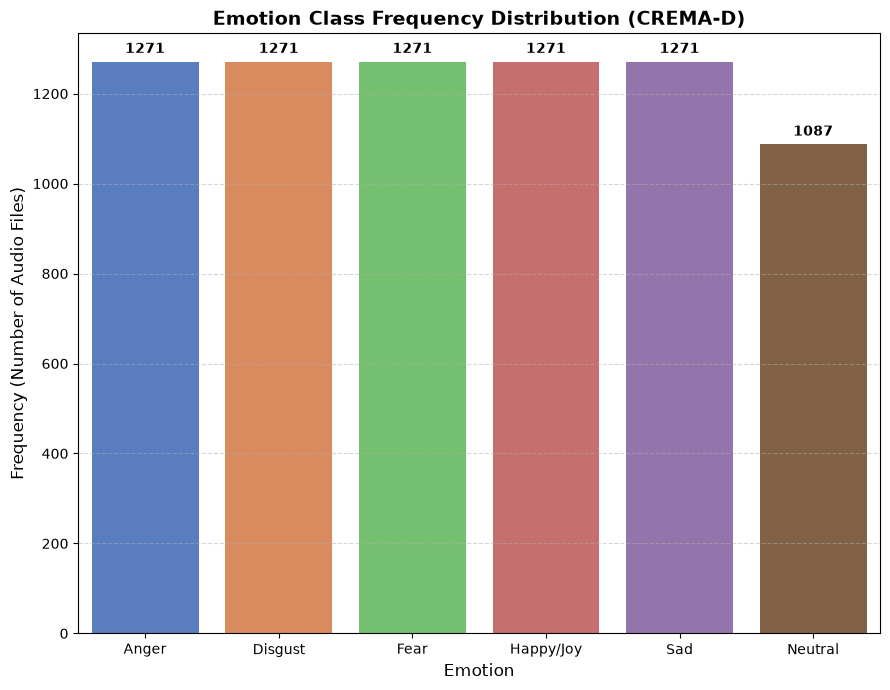

In [7]:
plt.figure(figsize=(9, 7))

palette = sns.color_palette("muted", n_colors=len(emotion_counts))

ax = sns.barplot(
    x=emotion_counts.index, 
    y=emotion_counts.values,
    hue=emotion_counts.index,
    palette=palette,
    legend=False
)


for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', 
        va='bottom', 
        xytext=(0, 4), 
        textcoords='offset points',
        fontweight='bold'
    )

plt.title('Emotion Class Frequency Distribution (CREMA-D)', fontsize=14, fontweight='bold')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Frequency (Number of Audio Files)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

We can view that the distribution of the class isn't a big difference. Is interesting to know that five of the six classes have the same number of the data. With that analysis we can try to apply data augmentation on the `Neutral` class to standardize the dataset. We can also view for each class how many emotion level exists for each one of the class, could be useful to understand why our model takes some decisions.

In [8]:
LEVEL_MAP = {
    'LO': 'Low',
    'MD': 'Medium',
    'HI': 'High',
    'XX': 'Unspecified'
}

def extract_emotions_and_levels(dataset_path):
    """
    Parses audio filenames from the CREMA-D dataset directory,
    extracts the emotion code (index 2) and emotion level (index 3).
    Example filename: 1001_DFA_ANG_XX.wav
    """
    data = []
    for file_name in os.listdir(dataset_path):
        if file_name.endswith('.wav'):
            parts = file_name.split('_')
            if len(parts) >= 4:
                emotion_code = parts[2]
                level_code    = parts[3].replace('.wav', '')
                if emotion_code in EMOTION_MAP and level_code in LEVEL_MAP:
                    data.append({
                        'filename'     : file_name,
                        'emotion'      : EMOTION_MAP[emotion_code],
                        'emotion_level': LEVEL_MAP[level_code]
                    })
    return pd.DataFrame(data)


df_emotions_levels = extract_emotions_and_levels(DATASET_ROOT)

LEVEL_ORDER   = ['Low', 'Medium', 'High', 'Unspecified']
EMOTION_ORDER = ['Anger', 'Disgust', 'Fear', 'Happy/Joy', 'Neutral', 'Sad']

pivot = (
    df_emotions_levels.groupby(['emotion', 'emotion_level'])
      .size()
      .unstack(fill_value=0)
      .reindex(index=EMOTION_ORDER, columns=LEVEL_ORDER, fill_value=0)
)

pivot

emotion_level,Low,Medium,High,Unspecified
emotion,,,,
Anger,91,91,91,998
Disgust,91,91,91,998
Fear,91,91,91,998
Happy/Joy,91,91,91,998
Neutral,0,0,0,1087
Sad,91,91,91,997


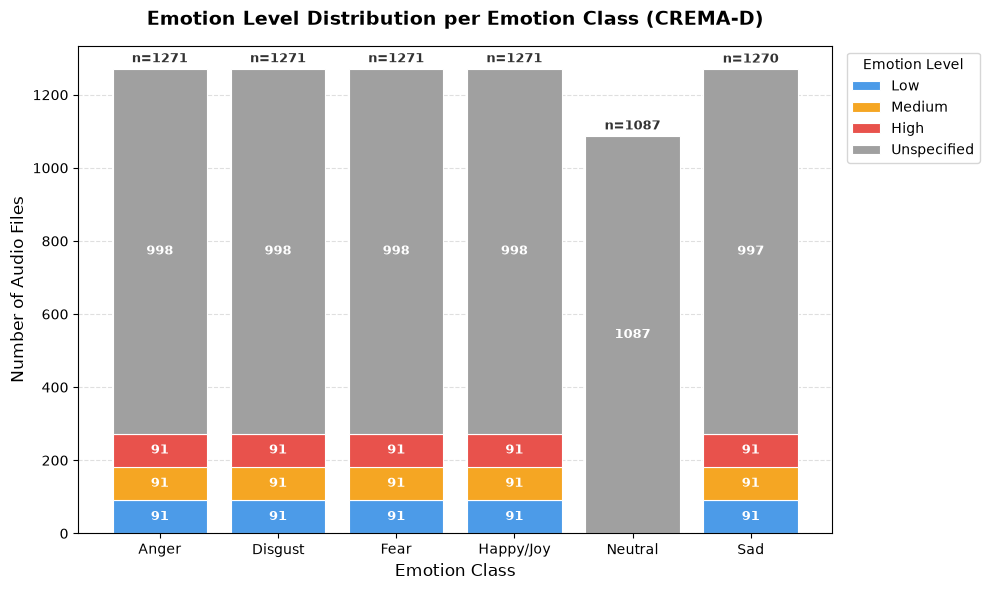

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

level_colors = {
    'Low'        : '#4C9BE8',
    'Medium'     : '#F5A623',
    'High'       : '#E8524C',
    'Unspecified': '#A0A0A0'
}

bottom = pd.Series([0] * len(pivot), index=pivot.index)

for level in LEVEL_ORDER:
    values = pivot[level]
    bars = ax.bar(
        pivot.index,
        values,
        bottom=bottom,
        label=level,
        color=level_colors[level],
        edgecolor='white',
        linewidth=0.8
    )

    for bar, val, bot in zip(bars, values, bottom):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bot + val / 2,
                str(val),
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='white'
            )
    bottom += values

for i, (emotion, total) in enumerate(pivot.sum(axis=1).items()):
    ax.text(
        i, total + 10,
        f'n={total}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#333333'
    )

ax.set_title('Emotion Level Distribution per Emotion Class (CREMA-D)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Number of Audio Files', fontsize=12)
ax.legend(title='Emotion Level', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

With the above plot, we can see that not only the number of each classes are equal between them. Also the number of emotion levels have the same behavior, however we have a lot of `Unspecified` emotions level, so add that feature to tranining our model could be aggregate noise to our learning phase of the ML model.

---

### **Analyze the length of the audios**

In [10]:
import wave
import numpy as np

audio_durations = []


for audio_filename in os.listdir(DATASET_ROOT):
    
    audio_file_path = os.path.join(DATASET_ROOT, audio_filename)

    with wave.open(audio_file_path, 'r') as wave_file:
        # Obtain duration in seconds -> total number of frames / sample rate
        duration_seconds = wave_file.getnframes() / wave_file.getframerate()
        audio_durations.append(duration_seconds)

audio_durations_array = np.array(audio_durations)

shortest_audio_duration = np.min(audio_durations_array)
longest_audio_duration = np.max(audio_durations_array)
mean_audio_duration = np.mean(audio_durations_array)

rounded_durations = np.round(audio_durations, decimals=2)
unique_values, occurrence_counts = np.unique(rounded_durations, return_counts=True)
mode_audio_duration = unique_values[np.argmax(occurrence_counts)]


print(f"Shortest duration : {shortest_audio_duration:.2f} seconds")
print(f"Longest duration  : {longest_audio_duration:.2f} seconds")
print(f"Mean duration     : {mean_audio_duration:.2f} seconds")
print(f"Mode duration     : {mode_audio_duration:.2f} seconds")

Shortest duration : 1.27 seconds
Longest duration  : 5.00 seconds
Mean duration     : 2.54 seconds
Mode duration     : 2.44 seconds


### **Analyze different types of audio representation**

In [11]:
import librosa
import librosa.display

all_files = [f for f in os.listdir(DATASET_ROOT) if f.endswith('.wav')]
sample_files = np.random.choice(all_files, size=4, replace=False)

audio_samples = []
for f in sample_files:
    y, sr = librosa.load(os.path.join(DATASET_ROOT, f), sr=None)
    audio_samples.append((f, y, sr))
    print(f"Loaded: {f} | Duration: {len(y)/sr:.2f}s | SR: {sr} Hz")

Loaded: 1007_ITS_FEA_XX.wav | Duration: 3.80s | SR: 16000 Hz
Loaded: 1051_IWW_FEA_XX.wav | Duration: 2.34s | SR: 16000 Hz
Loaded: 1045_WSI_DIS_XX.wav | Duration: 3.37s | SR: 16000 Hz
Loaded: 1037_IEO_NEU_XX.wav | Duration: 1.67s | SR: 16000 Hz


#### **Waveform**
**What it is:** The raw audio signal, amplitude plotted over time.

**What it captures:** Loudness changes, signal envelope, silences, and event onsets in the time domain.

**Most useful for:** Visual inspection, detecting silence or clipping, and as direct input to end-to-end deep learning models (e.g., 1D CNNs, wav2vec).

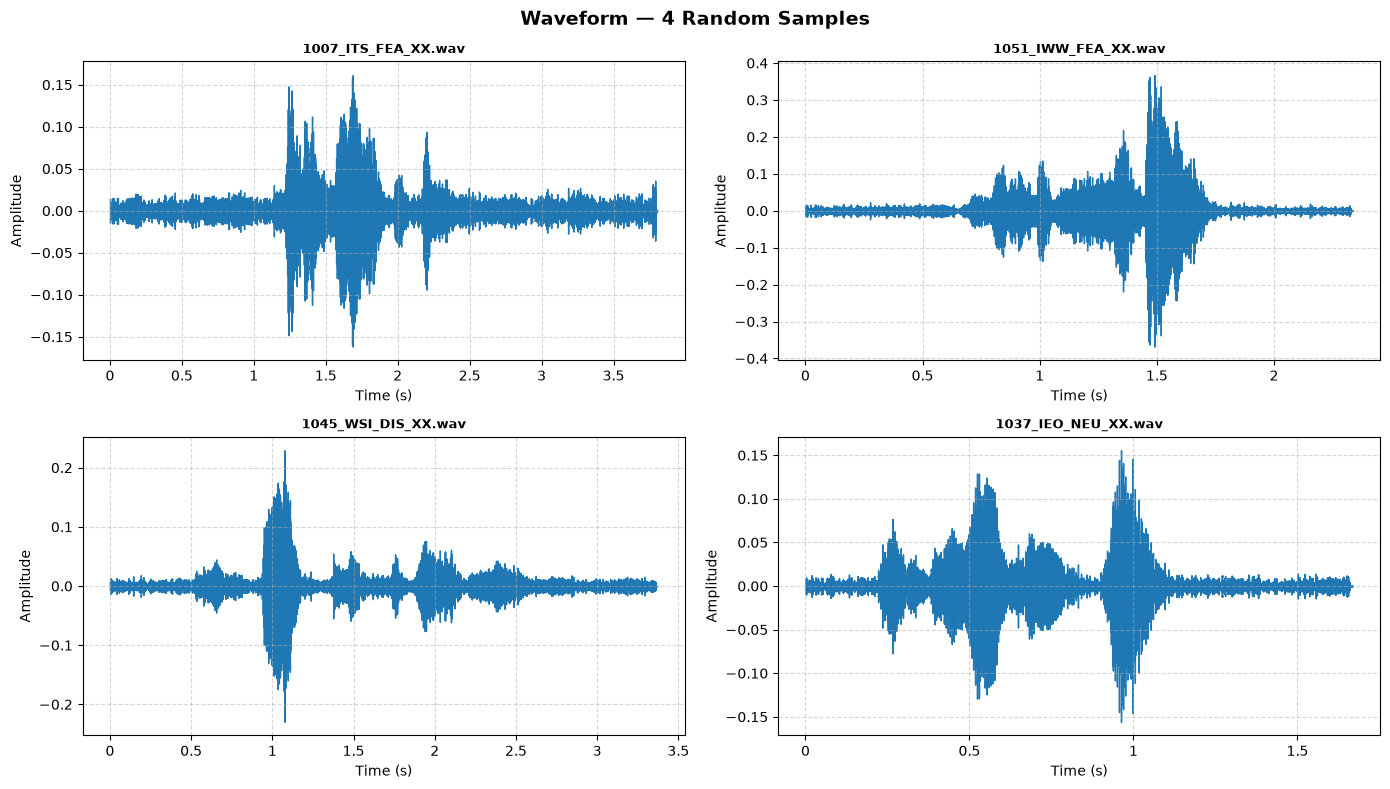

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (filename, y, sr) in zip(axes, audio_samples):
    librosa.display.waveshow(y, sr=sr, ax=ax, color='#1f77b4')
    ax.set_title(filename, fontsize=9, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Waveform — 4 Random Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **Spectrogram**
**What it is:** A time–frequency representation obtained with the Short-Time Fourier Transform (STFT). It shows how the energy at each frequency changes over time.

**What it captures:** The frequency content of the signal at each moment, including harmonics, pitch, and texture.

**Most useful for:** Input to CNNs (treated as an image), sound event detection, music analysis, and speech analysis.

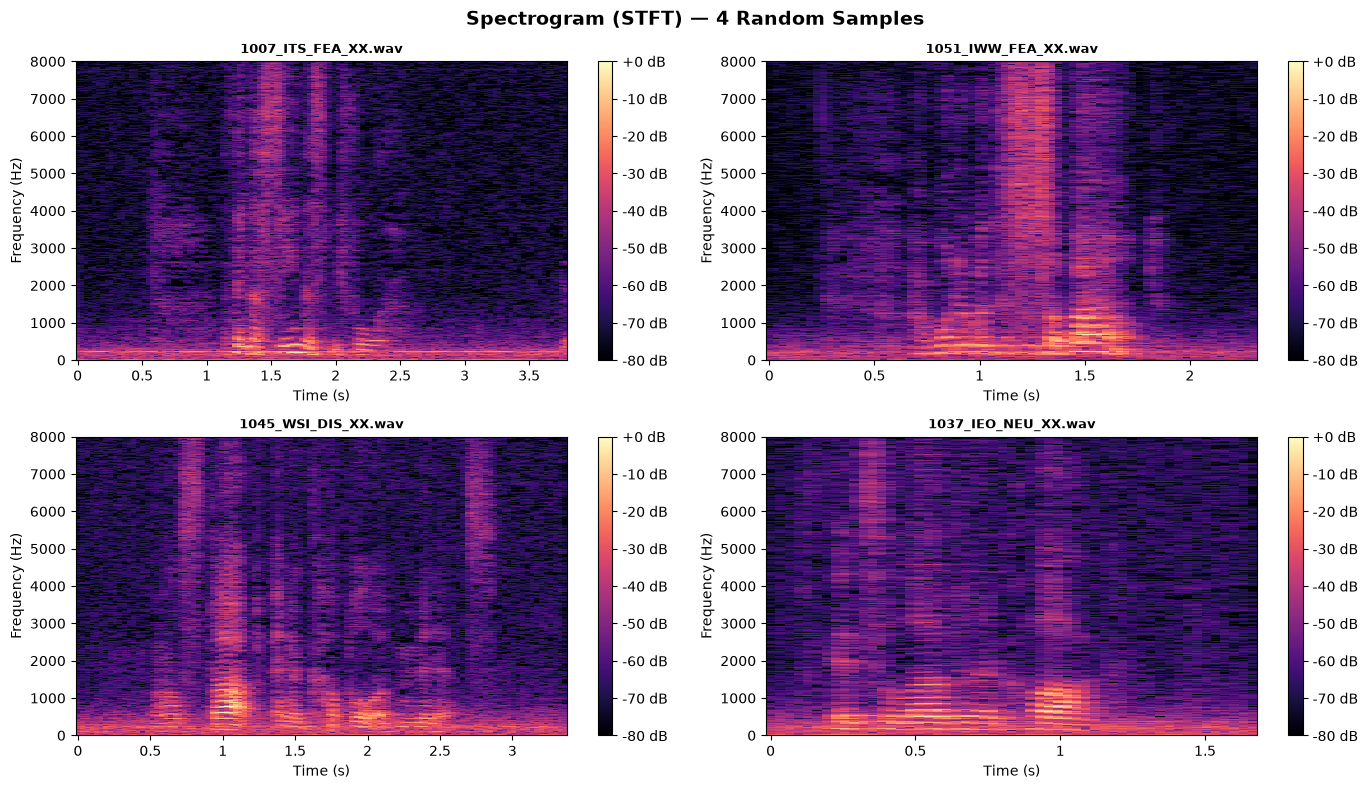

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (filename, y, sr) in zip(axes, audio_samples):
    stft_db = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(stft_db, sr=sr, x_axis='time', y_axis='hz', ax=ax, cmap='magma')
    ax.set_title(filename, fontsize=9, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

fig.suptitle('Spectrogram (STFT) — 4 Random Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **MFCC (Mel-Frequency Cepstral Coefficients)**
**What it is:** A compact set of coefficients (usually 13) per frame, computed from the log energies of a Mel-scale filter bank followed by a DCT.

**What it captures:** The shape of the spectral envelope, which corresponds to the **timbre** of the sound, using a scale that mimics human hearing.

**Most useful for:** Speech recognition, speaker identification, audio and music classification.

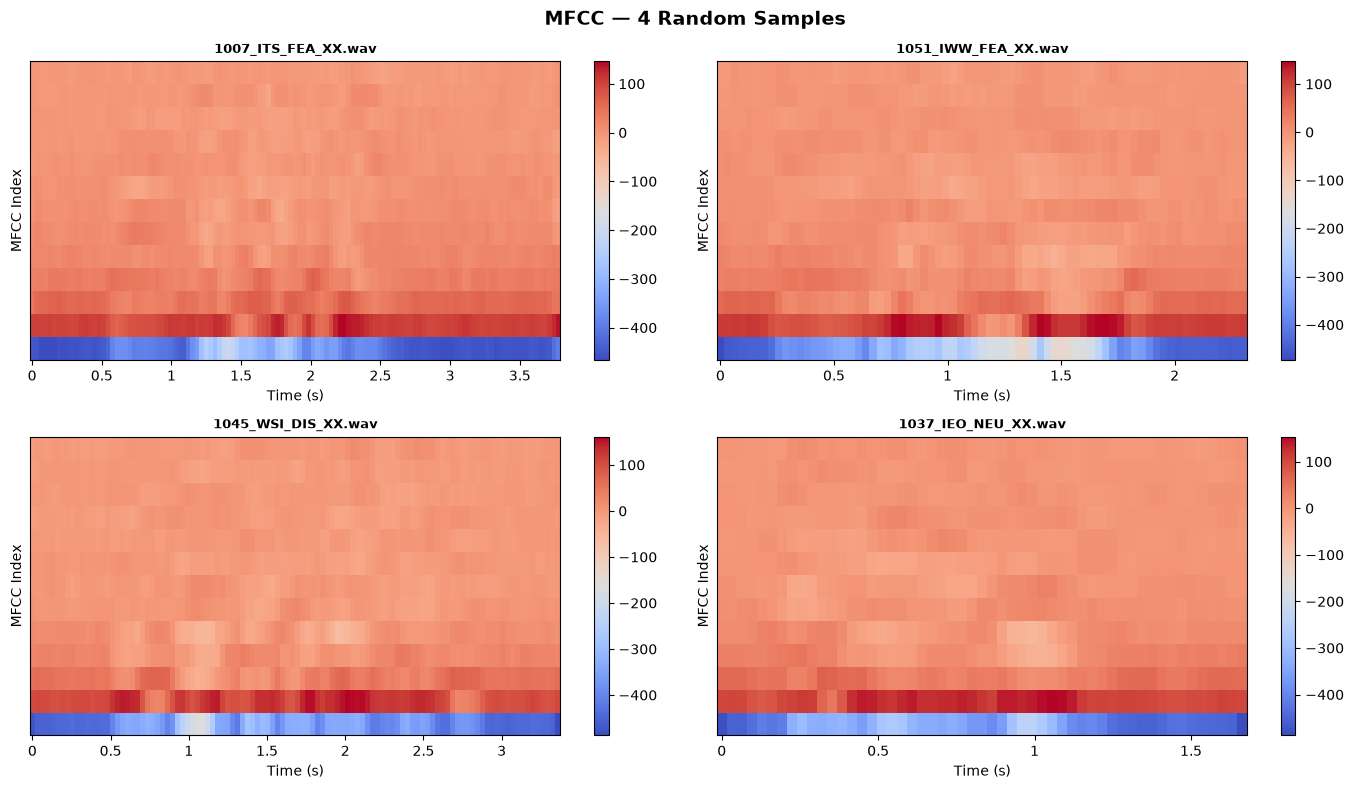

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (filename, y, sr) in zip(axes, audio_samples):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    img = librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=ax, cmap='coolwarm')
    ax.set_title(filename, fontsize=9, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('MFCC Index')
    fig.colorbar(img, ax=ax)

fig.suptitle('MFCC — 4 Random Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### **Zero Crossing Rate (ZCR)**
**What it is:** The rate at which the signal changes sign (crosses zero) within a frame.

**What it captures:** Noisiness and a rough estimate of high-frequency content.

**Most useful for:** Distinguishing voiced from unvoiced speech, separating speech from noise, and detecting percussive sounds.

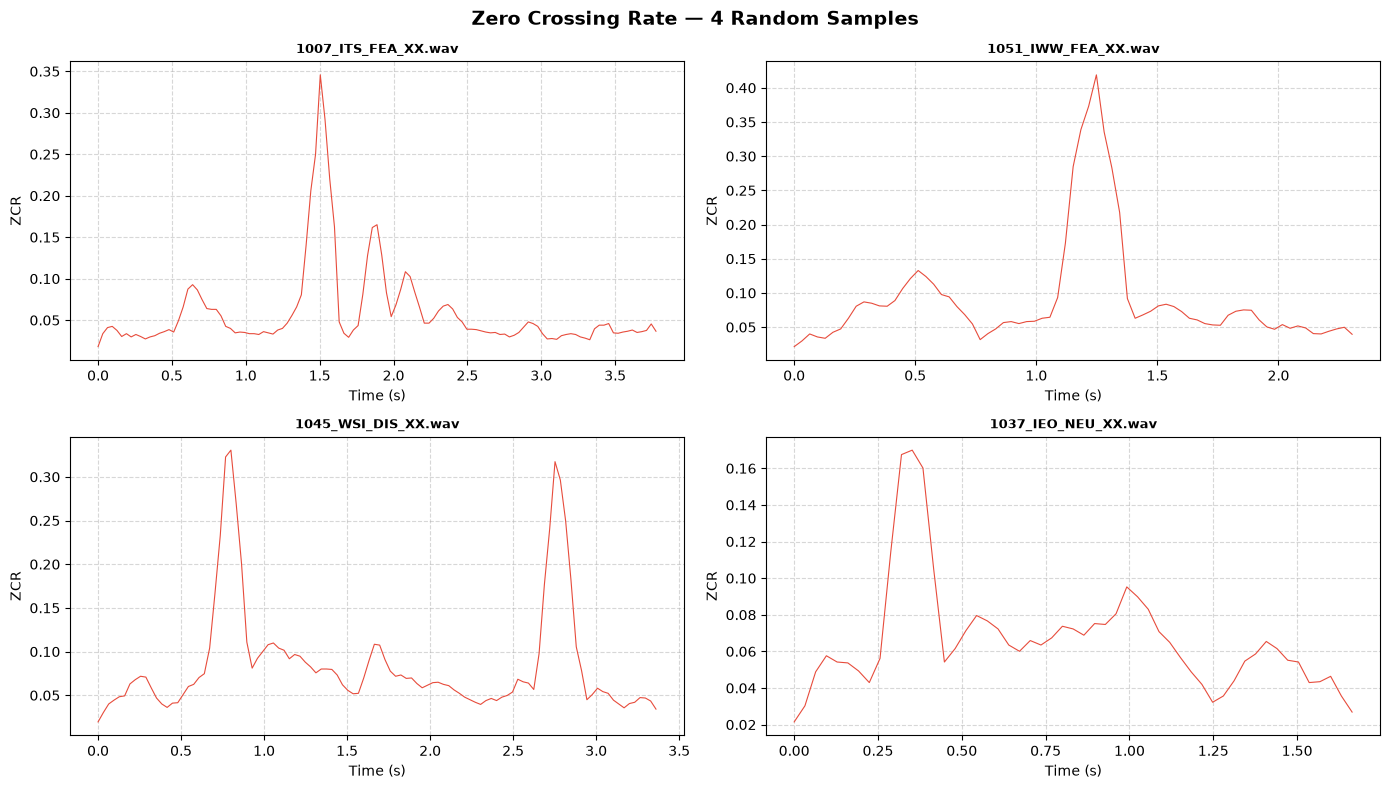

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (filename, y, sr) in zip(axes, audio_samples):
    zcr = librosa.feature.zero_crossing_rate(y=y)
    time_axis = librosa.frames_to_time(np.arange(zcr.shape[1]), sr=sr)
    ax.plot(time_axis, zcr[0], color='#e74c3c', linewidth=0.8)
    ax.set_title(filename, fontsize=9, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ZCR')
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Zero Crossing Rate — 4 Random Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **Spectral Centroid**
**What it is:** The magnitude-weighted average frequency of the spectrum, its "center of mass."

**What it captures:** The perceived **brightness** of the sound. High values indicate bright sounds and low values indicate dark sounds.

**Most useful for:** Timbre characterization, instrument classification, and music genre classification.

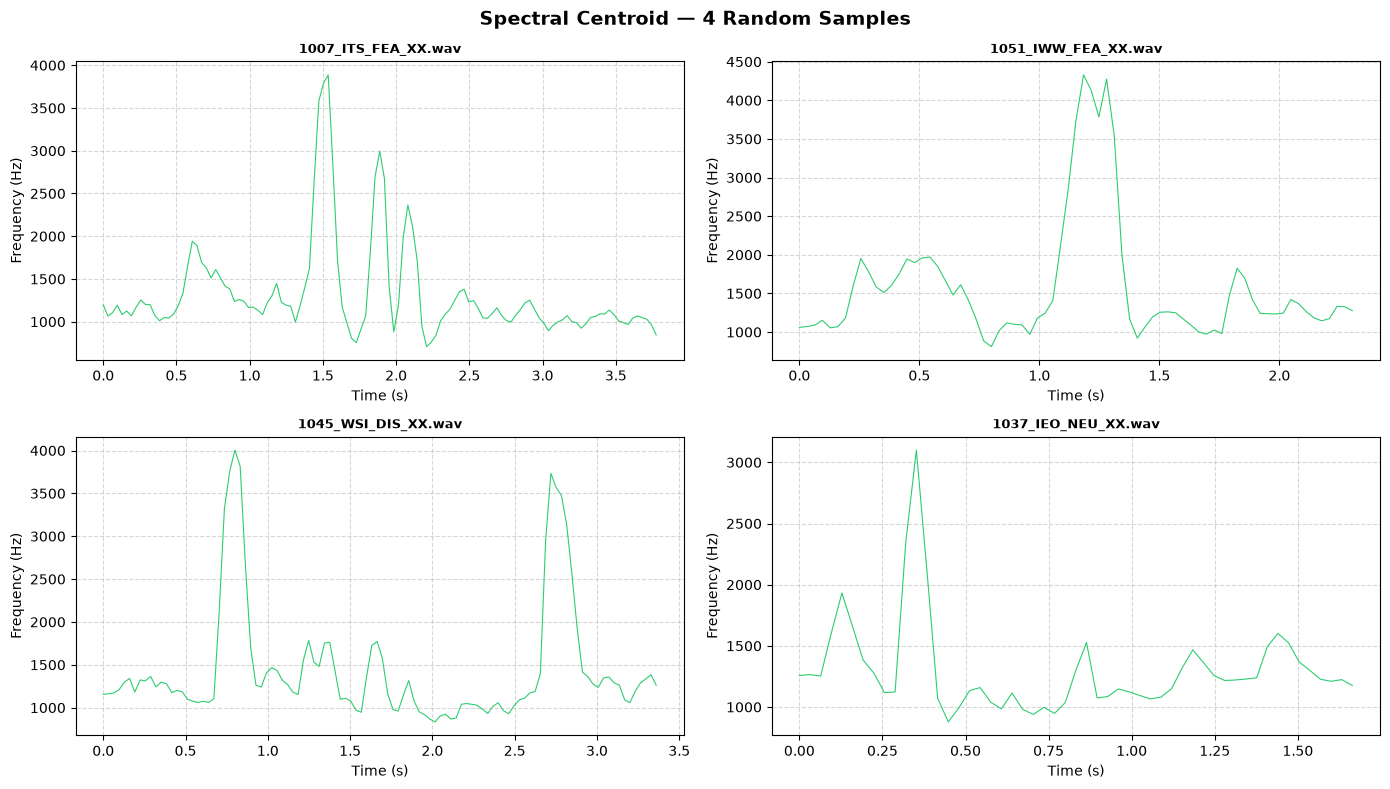

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (filename, y, sr) in zip(axes, audio_samples):
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    time_axis = librosa.frames_to_time(np.arange(centroid.shape[1]), sr=sr)
    ax.plot(time_axis, centroid[0], color='#2ecc71', linewidth=0.8)
    ax.set_title(filename, fontsize=9, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Spectral Centroid — 4 Random Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **RMS Energy**
**What it is:** The root mean square of the signal amplitude within each frame.

**What it captures:** The **loudness** or intensity of the signal over time.

**Most useful for:** Silence and voice activity detection, audio segmentation, and dynamics analysis.

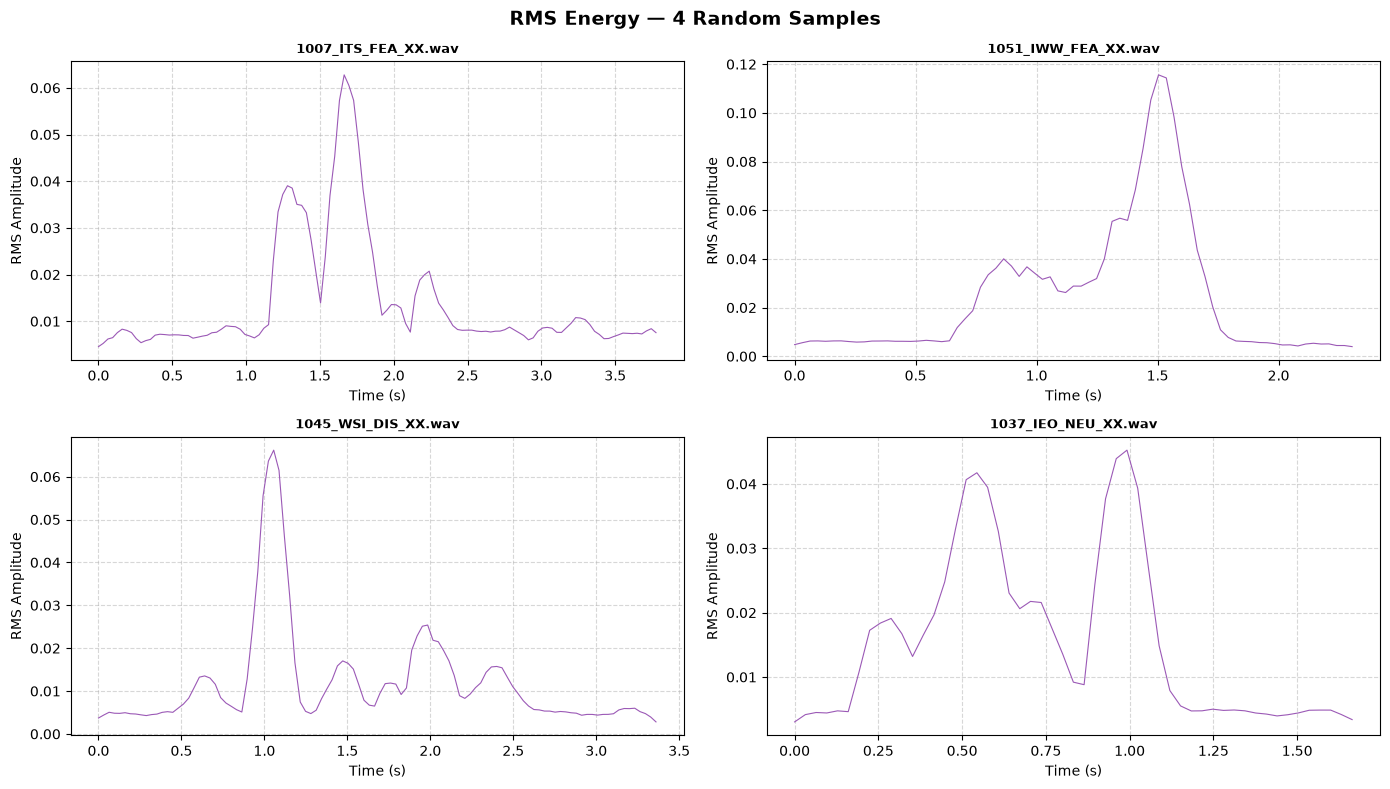

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (filename, y, sr) in zip(axes, audio_samples):
    rms = librosa.feature.rms(y=y)
    time_axis = librosa.frames_to_time(np.arange(rms.shape[1]), sr=sr)
    ax.plot(time_axis, rms[0], color='#9b59b6', linewidth=0.8)
    ax.set_title(filename, fontsize=9, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('RMS Amplitude')
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('RMS Energy — 4 Random Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **Spectral Rolloff**
**What it is:** The frequency below which a given percentage (typically 85%) of the total spectral energy lies.

**What it captures:** The effective **bandwidth**, or upper limit, of the spectrum.

**Most useful for:** Distinguishing harmonic sounds from noisy ones, voiced/unvoiced detection, and music classification.

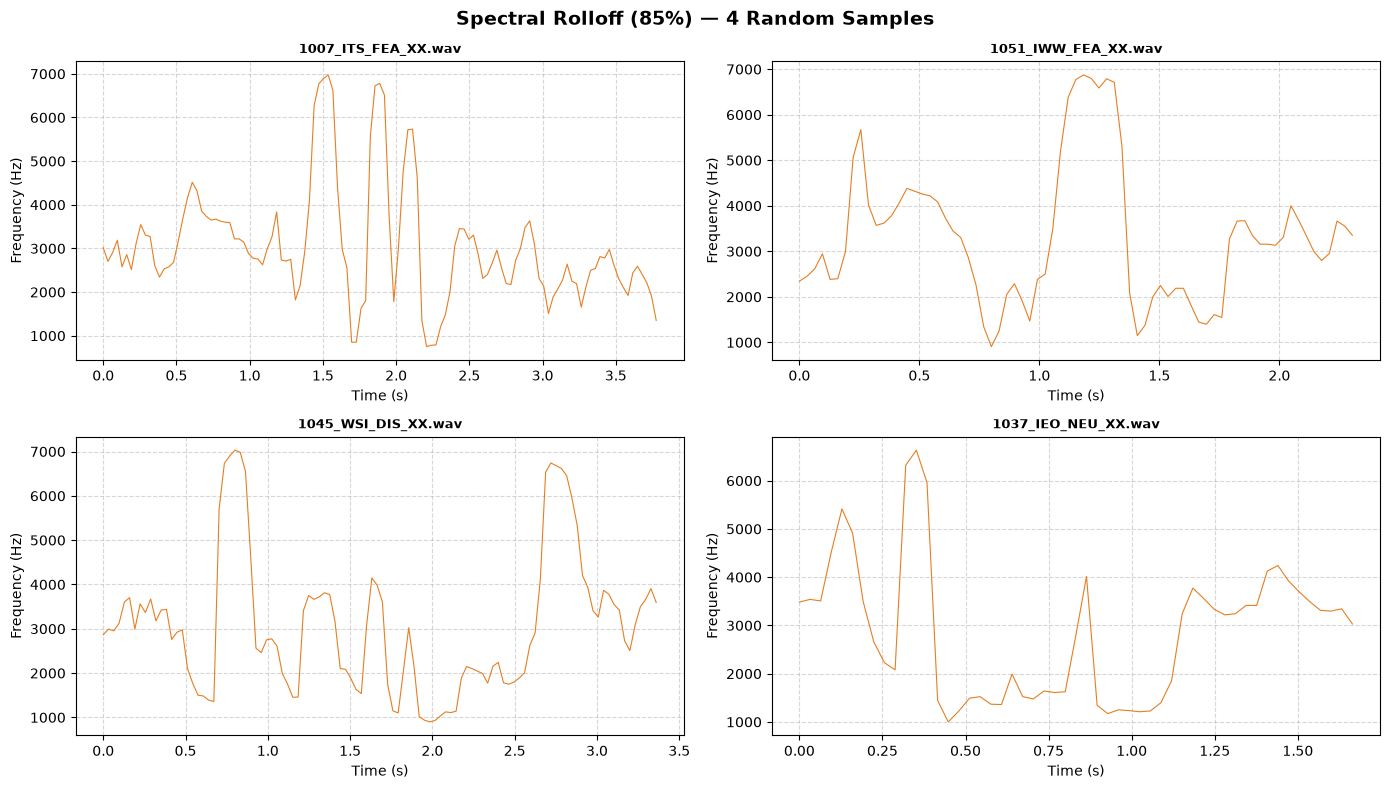

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (filename, y, sr) in zip(axes, audio_samples):
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    time_axis = librosa.frames_to_time(np.arange(rolloff.shape[1]), sr=sr)
    ax.plot(time_axis, rolloff[0], color='#e67e22', linewidth=0.8)
    ax.set_title(filename, fontsize=9, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Spectral Rolloff (85%) — 4 Random Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **2. Data Leakage prevention**

In speech emotion recognition tasks, a **random train/test split** at the file level introduces a subtle but severe form of **data leakage** known as **speaker leakage**. The main problem is that each human speaker has a unique and highly consistent **vocal fingerprint** thanks to the combination of physiological and behavioral characteristics that remain stable across different utterances, emotions, and sentences such as *Vocal tract resonances* or the *natural pitch range of a speaker*.

These characteristics lead us to consider that our model must operate **speaker-specific and emotion-independent**; if the same speaker appears in both the training and test sets (even when uttering different sentences with different emotions), the model may learn to associate that speaker’s vocal identity with a specific emotional label, rather than learning the actual acoustic patterns of the emotion itself.


The generalization goal is:
> *"Given an audio clip from a speaker the model has never heard before, correctly classify the expressed emotion."*

A random file-level split evaluates a fundamentally different (and much easier) task:
> *"Given an audio clip from a speaker the model has already partially memorized, correctly classify the expressed emotion."*
This discrepancy between **what the model is evaluated on** and **what it needs to do in production** is the definition of data leakage.


Taking the previous points, the way to obtain an honest evaluation, the dataset must be split at the **actor/speaker level**, ensuring that **every actor appears in exactly one partition** (either train or test, never both). This forces the model to generalize across speakers, producing metrics that are truly representative of real-world performance.

#### **2.1 Obtain the metadata of the dataset (in special ID of the speaker)**

In [19]:
# CREMA-D filename format: {ActorID}_{Sentence}_{Emotion}_{Level}.wav

EMOTION_MAP = {
    'ANG': 'Anger',
    'DIS': 'Disgust',
    'FEA': 'Fear',
    'HAP': 'Happy/Joy',
    'NEU': 'Neutral',
    'SAD': 'Sad'
}

records = []
for filename in os.listdir(DATASET_ROOT):
    if not filename.endswith('.wav'):
        continue
    parts = filename.split('_')
    if len(parts) < 3:
        continue
    actor_id     = parts[0]              
    emotion_code = parts[2]           
    if emotion_code not in EMOTION_MAP:
        continue
    records.append({
        'filename' : filename,
        'actor_id' : actor_id,
        'filepath' : os.path.join(DATASET_ROOT, filename),
        'emotion'  : EMOTION_MAP[emotion_code],
        'label'    : list(EMOTION_MAP.keys()).index(emotion_code)  # integer label
    })

df = pd.DataFrame(records)

print(f"Unique actors : {df['actor_id'].nunique()}")

Unique actors : 91


In [20]:
df.sample(10)

,filename,actor_id,filepath,emotion,label
3820,1047_TIE_HAP_XX.wav,1047,data/AudioWAV\1047_TIE_HAP_XX.wav,Happy/Joy,3
1731,1022_ITH_ANG_XX.wav,1022,data/AudioWAV\1022_ITH_ANG_XX.wav,Anger,0
6149,1076_IEO_NEU_XX.wav,1076,data/AudioWAV\1076_IEO_NEU_XX.wav,Neutral,4
5873,1072_TSI_ANG_XX.wav,1072,data/AudioWAV\1072_TSI_ANG_XX.wav,Anger,0
7000,1086_IWW_NEU_XX.wav,1086,data/AudioWAV\1086_IWW_NEU_XX.wav,Neutral,4
4764,1059_IOM_SAD_XX.wav,1059,data/AudioWAV\1059_IOM_SAD_XX.wav,Sad,5
3990,1049_TSI_HAP_XX.wav,1049,data/AudioWAV\1049_TSI_HAP_XX.wav,Happy/Joy,3
3664,1045_TSI_SAD_XX.wav,1045,data/AudioWAV\1045_TSI_SAD_XX.wav,Sad,5
7214,1089_IEO_NEU_XX.wav,1089,data/AudioWAV\1089_IEO_NEU_XX.wav,Neutral,4
7167,1088_MTI_DIS_XX.wav,1088,data/AudioWAV\1088_MTI_DIS_XX.wav,Disgust,1


#### **2.2 Train/Test split at the actor level (no speaker bleed)**

I use the `GroupSuffleSplit` method from `sci-kit learn` module, the task of that method is divide the data respecting groups taking the unique identifiers of the dataset, specified on ``groups` parameter.

In [21]:
from sklearn.model_selection import GroupShuffleSplit

X = df['filepath'].values
y = df['label'].values
groups = df['actor_id'].values

# Split is performed at the actor level
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)\

# Here we specify the unique identifier to consider on the split with the method
train_idx, test_idx = next(gss.split(X, y, groups))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

print(f"Train samples : {len(df_train)} | Actors: {df_train['actor_id'].nunique()}")
print(f"Test  samples : {len(df_test)}  | Actors: {df_test['actor_id'].nunique()}")

Train samples : 5890 | Actors: 72
Test  samples : 1552  | Actors: 19


Let's analyze the class distribution after the data division

In [22]:
# Original dataset
dist_original = (df_emotions['emotion'].value_counts(normalize=True) * 100).sort_index()

# Train & test splits
dist_train = (df_train['emotion'].value_counts(normalize=True) * 100).sort_index()
dist_test  = (df_test['emotion'].value_counts(normalize=True)  * 100).sort_index()

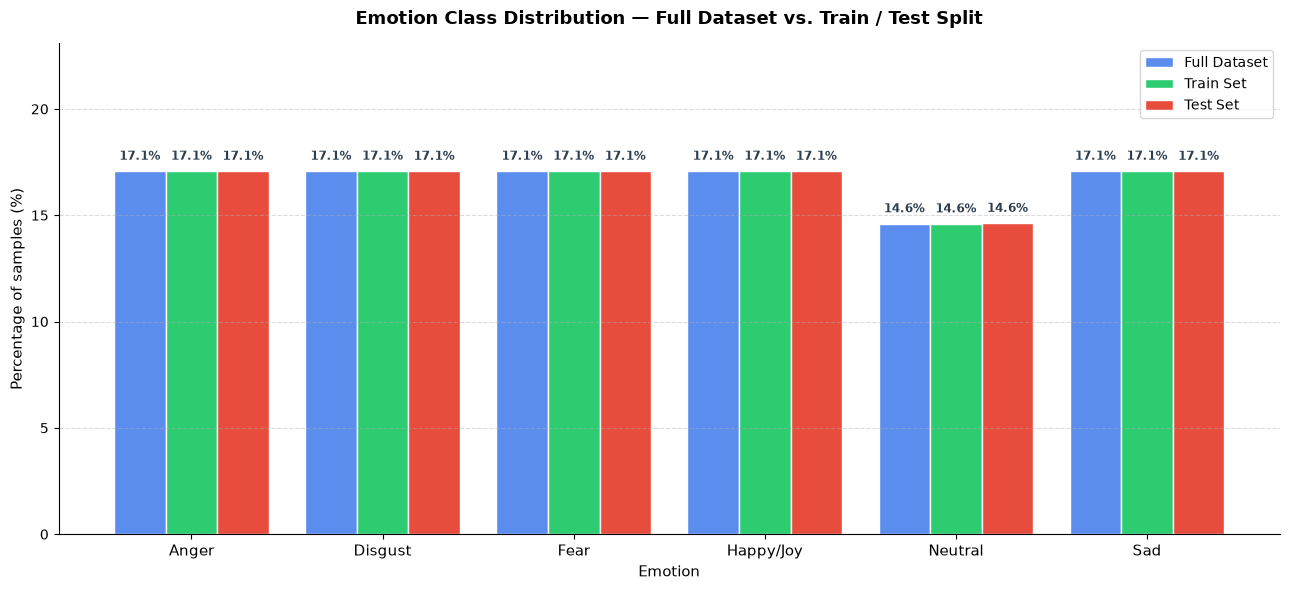

In [23]:
emotions = dist_original.index.tolist()
x = np.arange(len(emotions))
width = 0.27

fig, ax = plt.subplots(figsize=(13, 6))

bars_orig  = ax.bar(x - width, dist_original.reindex(emotions),   width, label='Full Dataset',  color='#5b8dee', edgecolor='white')
bars_train = ax.bar(x,         dist_train.reindex(emotions),       width, label='Train Set',     color='#2ecc71', edgecolor='white')
bars_test  = ax.bar(x + width, dist_test.reindex(emotions),        width, label='Test Set',      color='#e74c3c', edgecolor='white')

for bars in (bars_orig, bars_train, bars_test):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.4,
            f'{h:.1f}%',
            ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='#2c3e50'
        )

ax.set_xticks(x)
ax.set_xticklabels(emotions, fontsize=11)
ax.set_ylabel('Percentage of samples (%)', fontsize=11)
ax.set_xlabel('Emotion', fontsize=11)
ax.set_title(
    'Emotion Class Distribution — Full Dataset vs. Train / Test Split',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_ylim(0, max(dist_original.max(), dist_train.max(), dist_test.max()) + 6)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.45)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

The percentages for each emotion in the original dataset and in the `division` dataset used for training are preserved. This is beneficial for our machine learning model, as it allows us to model the initial behavior of our data. This behavior stems from the very nature of the data, which followed a strict order, where each speaker, at first glance, appears to have recorded audio clips for each type of emotion.

---

#### **2.3 Verify: Zero actor overlap between train and test**

In [24]:
train_actors = set(df_train['actor_id'].unique())
test_actors  = set(df_test['actor_id'].unique())
overlap      = train_actors & test_actors

print(f"Actors in train : {len(train_actors)}")
print(f"Actors in test  : {len(test_actors)}")
print(f"Overlapping actors : {len(overlap)} | {'No leakage!' if len(overlap) == 0 else 'LEAKAGE DETECTED'}")

Actors in train : 72
Actors in test  : 19
Overlapping actors : 0 | No leakage!


#### **2.4 GroupKFold setup for cross-validation on training data**

In [25]:
from sklearn.model_selection import GroupKFold

# GroupKFold ensures no actor appears in both the fold's train and validation splits
N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)

X_train    = df_train['filepath'].values
y_train    = df_train['label'].values
groups_train = df_train['actor_id'].values

print(f"GroupKFold with {N_FOLDS} folds on {len(df_train)} training samples\n")

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups_train)):
    train_speakers  = set(groups_train[tr_idx])
    val_speakers = set(groups_train[val_idx])
    overlap    = train_speakers & val_speakers
    print(
        f"Fold {fold + 1} | "
        f"Train: {len(tr_idx)} samples ({len(train_speakers)} actors) | "
        f"Val: {len(val_idx)} samples ({len(val_speakers)} actors) | "
        f"Overlap: {len(overlap)} actors"
    )


GroupKFold with 5 folds on 5890 training samples

Fold 1 | Train: 4742 samples (58 actors) | Val: 1148 samples (14 actors) | Overlap: 0 actors
Fold 2 | Train: 4742 samples (58 actors) | Val: 1148 samples (14 actors) | Overlap: 0 actors
Fold 3 | Train: 4742 samples (58 actors) | Val: 1148 samples (14 actors) | Overlap: 0 actors
Fold 4 | Train: 4667 samples (57 actors) | Val: 1223 samples (15 actors) | Overlap: 0 actors
Fold 5 | Train: 4667 samples (57 actors) | Val: 1223 samples (15 actors) | Overlap: 0 actors


#### **2.5 Feature Selection: RMS Energy**

**Feature Selection: RMS Energy**

RMS (Root Mean Square) Energy was selected as the audio representation for model training because it captures the **intensity variations across time** within each audio recording. Different emotions naturally produce distinct energy patterns: high-arousal emotions such as *Anger* tend to generate consistently high energy levels, while low-arousal emotions such as *Sadness* or *Neutral* produce lower and more stable intensity curves. By feeding the model these per-frame energy values, we provide a direct signal of how vocal intensity evolves throughout each utterance, offering a discriminative feature that reflects the emotional state of the speaker.

In [26]:
train_durations = [librosa.get_duration(path=fp) for fp in df_train['filepath']]

mean_train_duration = float(np.mean(train_durations))
print(f"Mean duration (Train Set only): {mean_train_duration:.4f} seconds")
print(f"Total training samples analyzed: {len(train_durations)}")

Mean duration (Train Set only): 2.5586 seconds
Total training samples analyzed: 5890


**1. Preprocessing: Audio Length Standardization**

Raw CREMA-D recordings have variable durations. Since RMS Energy produces a time-series of frames whose length depends directly on the audio duration, feeding variable-length arrays into a machine learning model is not possible without a fixed-size input.

To strictly avoid data leakage, the target duration is computed **exclusively from the training set**:
- **Target length (Train Mean):** `2.5586` seconds.
- **Audios longer than this threshold → truncated** to the target length.
- **Audios shorter than this threshold → zero-padded** at the end with silence.

Once defined using the training set, this identical fixed length is applied to both `df_train` and `df_test`, ensuring consistent feature dimensions without leaking test set statistics into the pipeline.

In [27]:
TARGET_DURATION = mean_train_duration
# Standard sample rate by the Nyquist theorem
SR = 22050      

# Number of samples every audio must have
TARGET_SAMPLES = int(TARGET_DURATION * SR)  

def load_and_standardize(filepath, target_samples=TARGET_SAMPLES, sr=SR):
    y, _ = librosa.load(filepath, sr=sr)

    if len(y) > target_samples:
        y = y[:target_samples]
    elif len(y) < target_samples:
        padding = target_samples - len(y)
        y = np.pad(y, (0, padding), mode='constant')

    return y, sr

In [28]:
print("Standardization of the TRAIN set")
train_waveforms = []
for fp in df_train['filepath']:
    y, _ = load_and_standardize(fp)
    train_waveforms.append(y)

print(f"Total: {len(train_waveforms)} audios | Shape per audio: {train_waveforms[0].shape}")

Standardization of the TRAIN set
Total: 5890 audios | Shape per audio: (56418,)


In [29]:
print("\nStandardization of the TEST set")
test_waveforms = []
for fp in df_test['filepath']:
    y, _ = load_and_standardize(fp)
    test_waveforms.append(y)

print(f"Total: {len(test_waveforms)} audios | Shape per audio: {test_waveforms[0].shape}")


Standardization of the TEST set
Total: 1552 audios | Shape per audio: (56418,)


In [30]:
print(f"\nTarget samples : {TARGET_SAMPLES}")
print(f"Target duration: {TARGET_DURATION:.4f} s  @ {SR} Hz")


Target samples : 56418
Target duration: 2.5586 s  @ 22050 Hz


Let's see the values of standarized and transform audios

In [31]:
sample_indices = [0, 1]
for idx in sample_indices:
    audio = train_waveforms[idx]
    filename = df_train.iloc[idx]['filename']
    emotion = df_train.iloc[idx]['emotion']
    
    padded_with_zeros = np.all(audio[-100:] == 0)
    
    print(f"\nSample #{idx} -> {filename} | Emotion: {emotion}")
    print(f"  - Total samples (length) : {len(audio)} (exact shape: {audio.shape})")
    print(f"  - Duration in seconds    : {len(audio) / SR:.4f} s")
    print(f"  - Min amplitude / Max amp: {audio.min():.4f} / {audio.max():.4f}")
    print(f"  - First 5 values         : {np.round(audio[:5], 4)}")
    print(f"  - Last 5 values          : {np.round(audio[-5:], 4)} (Padded with silence? {padded_with_zeros})")


Sample #0 -> 1002_DFA_ANG_XX.wav | Emotion: Anger
  - Total samples (length) : 56418 (exact shape: (56418,))
  - Duration in seconds    : 2.5586 s
  - Min amplitude / Max amp: -0.8889 / 1.0531
  - First 5 values         : [ 0.0003 -0.0001 -0.0001  0.     -0.0001]
  - Last 5 values          : [0.004  0.0029 0.0025 0.0033 0.0038] (Padded with silence? False)

Sample #1 -> 1002_DFA_DIS_XX.wav | Emotion: Disgust
  - Total samples (length) : 56418 (exact shape: (56418,))
  - Duration in seconds    : 2.5586 s
  - Min amplitude / Max amp: -0.1392 / 0.2247
  - First 5 values         : [-0.0014 -0.0016 -0.0012 -0.0006 -0.0002]
  - Last 5 values          : [0. 0. 0. 0. 0.] (Padded with silence? True)


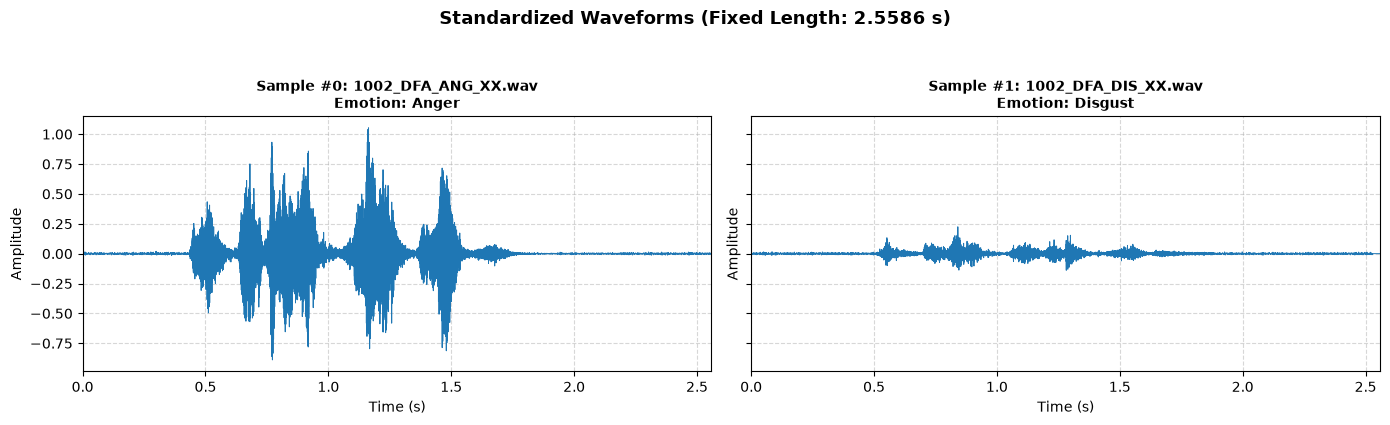

In [32]:
time_axis = np.linspace(0, TARGET_DURATION, TARGET_SAMPLES)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, idx in zip(axes, sample_indices):
    audio = train_waveforms[idx]
    filename = df_train.iloc[idx]['filename']
    emotion = df_train.iloc[idx]['emotion']
    
    ax.plot(time_axis, audio, color='#1f77b4', linewidth=0.7)
    ax.set_title(f"Sample #{idx}: {filename}\nEmotion: {emotion}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(0, TARGET_DURATION)
plt.suptitle("Standardized Waveforms (Fixed Length: 2.5586 s)", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**2. Preprocessing: Audio transformation to RMS representation**

In [33]:
def extract_rms(waveforms, sr=SR, hop_length=512, frame_length=2048):
    rms_list = []
    for y in waveforms:
        rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)
        rms_list.append(rms[0])   # rms shape is (1, n_frames) → take rms[0] for 1D

    return np.array(rms_list)


print("Extracting RMS features from TRAIN waveforms...")
X_train_rms = extract_rms(train_waveforms)

X_test_rms  = extract_rms(test_waveforms)

y_train = df_train['label'].values
y_test  = df_test['label'].values

print(f"\nX_train_rms shape : {X_train_rms.shape}  → (n_audios_train, n_frames)")
print(f"X_test_rms  shape : {X_test_rms.shape}   → (n_audios_test,  n_frames)")
print(f"y_train     shape : {y_train.shape}")
print(f"y_test      shape : {y_test.shape}")
print(f"\nSample RMS values (first audio, first 5 frames):")
print(np.round(X_train_rms[0, :5], 6))

Extracting RMS features from TRAIN waveforms...

X_train_rms shape : (5890, 111)  → (n_audios_train, n_frames)
X_test_rms  shape : (1552, 111)   → (n_audios_test,  n_frames)
y_train     shape : (5890,)
y_test      shape : (1552,)

Sample RMS values (first audio, first 5 frames):
[0.00306  0.003711 0.004221 0.003703 0.003832]


**3. Preprocessing: Feature Scaling with StandardScaler**

No special justification is applied here beyond a standard baseline decision: `StandardScaler` is fitted exclusively on the training RMS features and then applied to both train and test sets. The goal is simply to evaluate whether bringing all frame-level energy values to a common scale (mean = 0, std = 1) improves classification performance compared to the raw RMS representation.
 
> The scaler is **fitted on `X_train_rms` only** and then applied to `X_test_rms`, preserving the data leakage prevention established in the split step.

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_rms)

X_train_scaled = scaler.transform(X_train_rms)
X_test_scaled  = scaler.transform(X_test_rms) 

In [35]:
print(f"\nX_train_scaled — mean  (should be ≈ 0.0): {X_train_scaled.mean():.6f}")
print(f"X_train_scaled — std   (should be ≈ 1.0): {X_train_scaled.std():.6f}")
print(f"\nX_test_scaled  — mean  (won't be exactly 0, that's expected): {X_test_scaled.mean():.6f}")
print(f"X_test_scaled  — std   (won't be exactly 1, that's expected): {X_test_scaled.std():.6f}")


X_train_scaled — mean  (should be ≈ 0.0): 0.000000
X_train_scaled — std   (should be ≈ 1.0): 1.000000

X_test_scaled  — mean  (won't be exactly 0, that's expected): 0.054569
X_test_scaled  — std   (won't be exactly 1, that's expected): 1.266536


---


### **3. Classifier Models**


Two classical supervised classification algorithms are selected for this experiment:

- **Simple model — Decision Tree (`DecisionTreeClassifier`):** A non-parametric model that learns a hierarchical set of threshold rules directly from the feature values. It is interpretable, requires no assumptions about the data distribution, and is insensitive to feature scaling, making it a natural baseline for structured feature vectors such as the frame-level RMS Energy representation.
- **Ensemble model — Random Forest (`RandomForestClassifier`):** An ensemble of decorrelated decision trees trained via bagging and random feature subsampling. By aggregating the predictions of multiple trees, Random Forest reduces the high variance that individual decision trees typically exhibit, which is particularly relevant when the input feature space is high-dimensional and the training signal is noisy — as is the case with time-series audio features.


Both models are well-established in the machine learning course. While state-of-the-art results in Speech Emotion Recognition are achieved by deep learning architectures (CNNs, LSTMs, Transformers), this experiment deliberately evaluates classical models to understand their behavior and limitations when applied to a non-trivial audio classification task, where the input is a variable-length time-series of acoustic energy values rather than the tabular or image data these models were originally designed for.


In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

models = {
    'Decision Tree' : DecisionTreeClassifier(random_state=8),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=8, n_jobs=-1),
}

models

{'Decision Tree': DecisionTreeClassifier(random_state=8),
 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=8)}

In [37]:
for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train_scaled, y_train, groups_train)):

    X_fold_train = X_train_scaled[tr_idx]
    y_fold_train = y_train[tr_idx]
    for name, model in models.items():
        model.fit(X_fold_train, y_fold_train)
    print(f"Fold {fold+1}/{N_FOLDS} | Train samples: {len(tr_idx)} | Val samples: {len(val_idx)}")



print("\nRetraining final models on full X_train_scaled...")
final_models = {}
for name, ModelClass in [
    ('Decision Tree', DecisionTreeClassifier(random_state=8)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=8, n_jobs=-1))
]:
    start = time.time()
    ModelClass.fit(X_train_scaled, y_train)
    elapsed = time.time() - start
    final_models[name] = ModelClass
    if name == 'Decision Tree':
        info = f"Max depth: {ModelClass.get_depth()} | Leaves: {ModelClass.get_n_leaves()}"
    else:
        info = f"Estimators: {ModelClass.n_estimators} | Features per split: {ModelClass.max_features}"
    print(f"\n{name}")
    print(f"     {info}")
    print(f"     Training time: {elapsed:.2f}s")

Fold 1/5 | Train samples: 4742 | Val samples: 1148
Fold 2/5 | Train samples: 4742 | Val samples: 1148
Fold 3/5 | Train samples: 4742 | Val samples: 1148
Fold 4/5 | Train samples: 4667 | Val samples: 1223
Fold 5/5 | Train samples: 4667 | Val samples: 1223

Retraining final models on full X_train_scaled...

Decision Tree
     Max depth: 29 | Leaves: 1702
     Training time: 1.24s

Random Forest
     Estimators: 100 | Features per split: sqrt
     Training time: 1.26s


### **4. Evaluation**

In [38]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

EMOTION_LABELS = ['Anger', 'Disgust', 'Fear', 'Happy/Joy', 'Neutral', 'Sad']

eval_results = {}

for name, model in final_models.items():
    y_pred = model.predict(X_test_scaled)
    eval_results[name] = {
        'y_pred': y_pred,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision Macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1 Macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
    }


table_data = {
    'Model': ['Decision Tree (Simple)', 'Random Forest (Ensemble)'],
    'Accuracy': [f"{eval_results['Decision Tree']['Accuracy']:.4f}", 
                f"{eval_results['Random Forest']['Accuracy']:.4f}"],


    'Precision Macro': [f"{eval_results['Decision Tree']['Precision Macro']:.4f}",
                f"{eval_results['Random Forest']['Precision Macro']:.4f}"],


    'Recall Macro': [f"{eval_results['Decision Tree']['Recall Macro']:.4f}",
                f"{eval_results['Random Forest']['Recall Macro']:.4f}"],


    'F1 Macro': [f"{eval_results['Decision Tree']['F1 Macro']:.4f}",
                f"{eval_results['Random Forest']['F1 Macro']:.4f}"],
}

df_comparison = pd.DataFrame(table_data).set_index('Model')

df_comparison


,Accuracy,Precision Macro,Recall Macro,F1 Macro
Model,,,,
Decision Tree (Simple),0.3170,0.3147,0.3176,0.3157
Random Forest (Ensemble),0.4626,0.4462,0.4662,0.4420


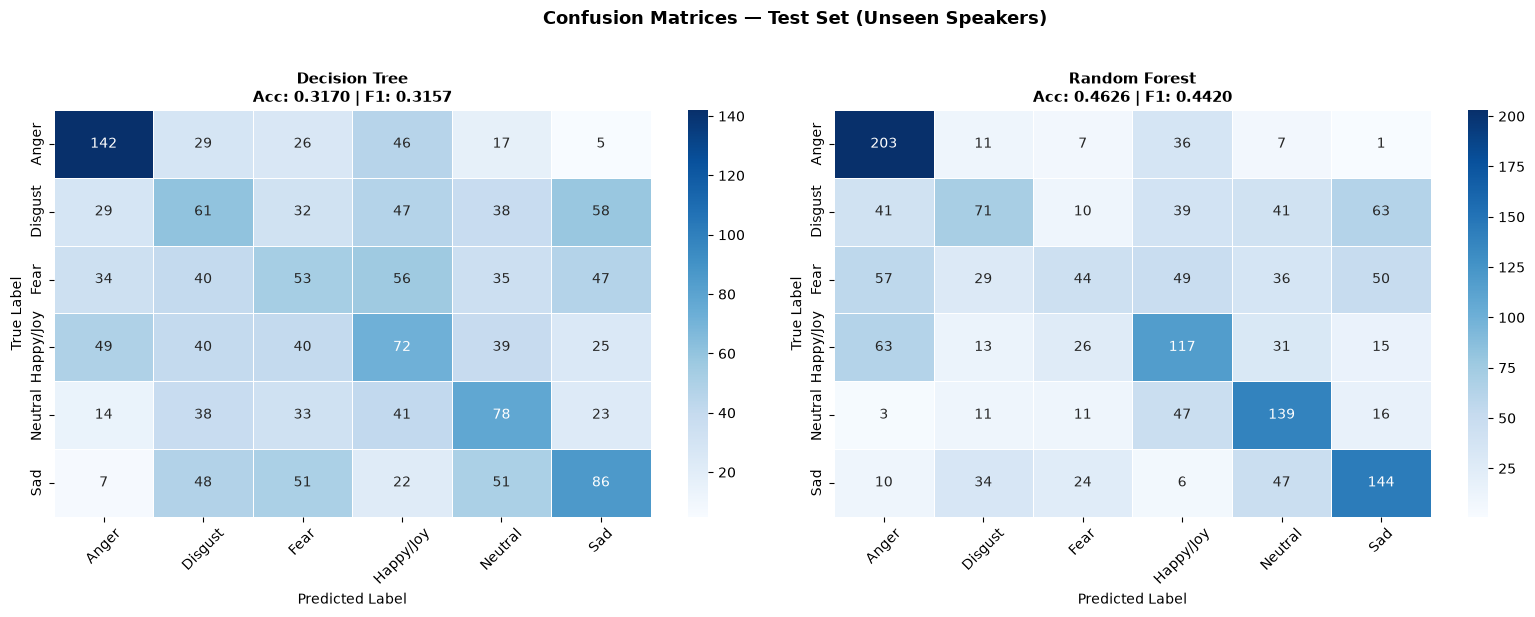

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, res) in zip(axes, eval_results.items()):
    cm = res['Confusion Matrix']
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=EMOTION_LABELS,
        yticklabels=EMOTION_LABELS,
        ax=ax, linewidths=0.5
    )
    ax.set_title(
        f"{name}\nAcc: {res['Accuracy']:.4f} | F1: {res['F1 Macro']:.4f}",
        fontweight='bold', fontsize=11
    )
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — Test Set (Unseen Speakers)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Results Analysis**

**Which model performed best?**

The **Random Forest** model outperformed the Decision Tree across all metrics, achieving a higher F1 Macro score (`0.3175` vs `0.4420`). This is expected, as ensemble methods reduce the variance inherent to individual trees by aggregating predictions from multiple models.

**Which emotions were hardest to classify?**

Based on the confusion matrices, the most misclassified emotions were `Anger` and `Sad`. This likely reflects acoustic similarity between those emotional states in terms of RMS energy patterns.

**Key differences between the simple and ensemble model?**

A single Decision Tree tries too hard to memorize the training data. Because of this, it gets easily confused when it hears a new voice that sounds slightly different. In contrast, Random Forest combines many different trees to make a collective decision. If one tree makes a mistake, the other trees help correct it, making the overall predictions much more stable and reliable.


**Why does speaker-level separation provide a more realistic evaluation?**

If the same person appears in both training and testing, the model can "cheat" by recognizing the person's unique voice rather than the actual emotion. Separating by actors forces the model to work with voices it has never heard before. This simulates how the system would actually work in real life when a completely new person uses it.


### **5. Validation with new personalized audio**

In [40]:
!pip install ipywidgets sounddevice -q

Could not find platform independent libraries <prefix>

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


This section records a new audio clip directly from the microphone and predicts its emotion using the trained models. The exact same preprocessing pipeline applied during training is used here:

1. **Record** → capture audio from microphone
2. **Standardize length** → truncate or zero-pad to `2.5586 s` (same `TARGET_SAMPLES`)
3. **Extract RMS features** → same `frame_length` and `hop_length`
4. **Scale** → apply the `scaler` already fitted on training data
5. **Predict** → both Decision Tree and Random Forest output an emotion label

> The new audio is **never used to retrain** either model.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

label_to_emotion = {
    0: "Anger",
    1: "Disgust",
    2: "Fear",
    3: "Happy/Joy",
    4: "Neutral",
    5: "Sad"
}

EMOTION_EMOJI = {
    "Anger": "😠", "Disgust": "🤢", "Fear": "😨",
    "Happy/Joy": "😊", "Neutral": "😐", "Sad": "😢"
}

state = {'is_recording': False, 'frames': None}

btn = widgets.Button(
    description  = '⏺  Record',
    button_style = 'success',
    layout       = widgets.Layout(width='180px', height='42px', margin='0 12px 0 0')
)
status = widgets.HTML("<span style='line-height:42px; color:#555;'>Press Record to start.</span>")
output = widgets.Output()

def on_click(b):
    if not state['is_recording']:
        state['frames']       = sd.rec(int(10 * SR), samplerate=SR, channels=1, dtype='float32')
        state['is_recording'] = True

        btn.description  = '⏹  Stop & Predict'
        btn.button_style = 'danger'
        status.value     = "<span style='color:#e74c3c; line-height:42px;'>🔴 <b>Recording...</b></span>"

        with output:
            clear_output(wait=True)

    else:
        sd.stop()
        state['is_recording'] = False
        btn.description  = '⏺  Record New'
        btn.button_style = 'success'
        status.value     = "<span style='line-height:42px;'>⚙️ Processing...</span>"

        raw     = state['frames'].flatten()
        nonzero = np.nonzero(raw)[0]
        y       = raw[: nonzero[-1] + 1] if len(nonzero) > 0 else raw

        if len(y) > TARGET_SAMPLES:
            y = y[:TARGET_SAMPLES]
        else:
            y = np.pad(y, (0, TARGET_SAMPLES - len(y)), mode='constant')

        rms   = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)
        X_new = rms[0].reshape(1, -1)

        X_new_scaled = scaler.transform(X_new)

        with output:
            clear_output(wait=True)
            print("🎯  Predicted Emotion")
            print("─" * 38)
            for name, model in final_models.items():
                pred_label   = model.predict(X_new_scaled)[0]
                pred_emotion = label_to_emotion[pred_label]
                emoji        = EMOTION_EMOJI.get(pred_emotion, "🎭")
                print(f"  {name:<22}: {emoji}  {pred_emotion}")
            print("─" * 38)

            time_axis = np.linspace(0, len(y) / SR, len(y))
            rms_time  = librosa.frames_to_time(np.arange(X_new.shape[1]), sr=SR, hop_length=512)

            fig, axes = plt.subplots(1, 2, figsize=(13, 3))

            axes[0].plot(time_axis, y, color='#1f77b4', linewidth=0.7)
            axes[0].set_title('Waveform (standardized)')
            axes[0].set_xlabel('Time (s)')
            axes[0].grid(True, linestyle='--', alpha=0.4)

            axes[1].plot(rms_time, X_new[0], color='#e74c3c', linewidth=1.2)
            axes[1].set_title('RMS Energy (extracted features)')
            axes[1].set_xlabel('Time (s)')
            axes[1].grid(True, linestyle='--', alpha=0.4)

            plt.tight_layout()
            plt.show()

        status.value = "<span style='line-height:42px; color:#27ae60;'>✅ Done! Press <b>Record New</b> to try again.</span>"


btn.on_click(on_click)
display(widgets.VBox([
    widgets.HBox([btn, status]),
    output
]))